In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import talib

In [2]:
df = pd.read_csv("../data/raw/AAPL.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


In [5]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
df["SMA_20"] = talib.SMA(df["Close"], timeperiod=20)

df["EMA_20"] = talib.EMA(df["Close"], timeperiod=20)

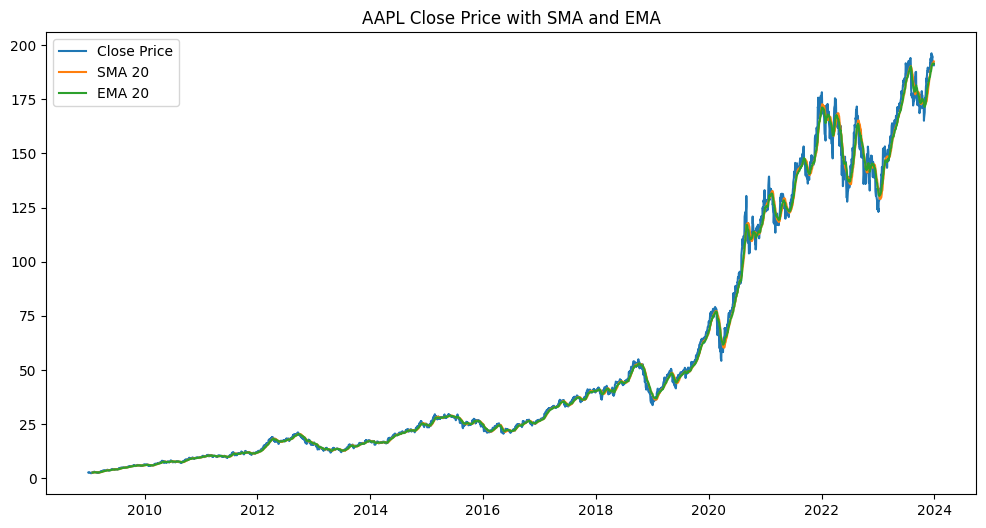

In [7]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"], label="Close Price")
plt.plot(df["SMA_20"], label="SMA 20")
plt.plot(df["EMA_20"], label="EMA 20")

plt.title("AAPL Close Price with SMA and EMA")

plt.legend()

plt.show()

In [8]:
df["RSI"] = talib.RSI(df["Close"], timeperiod=14)

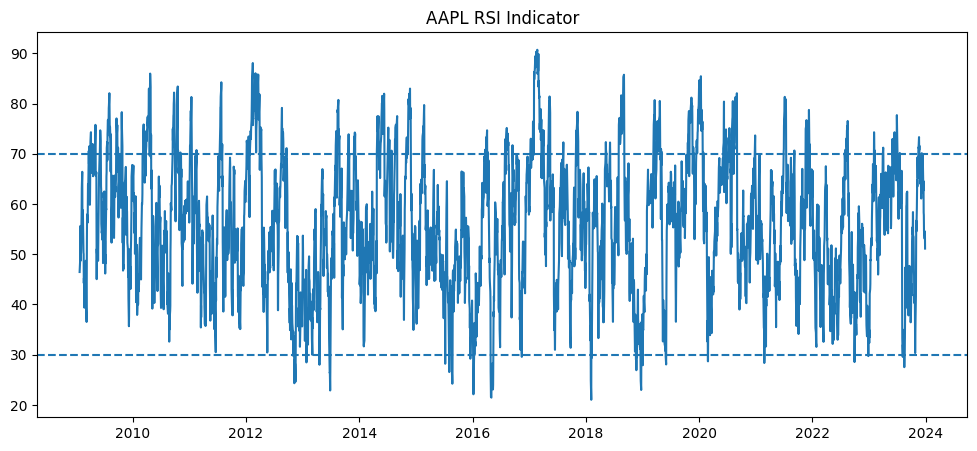

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df["RSI"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("AAPL RSI Indicator")

plt.show()

In [10]:
macd, macdsignal, macdhist = talib.MACD(
    df["Close"],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

df["MACD"] = macd
df["MACD_SIGNAL"] = macdsignal

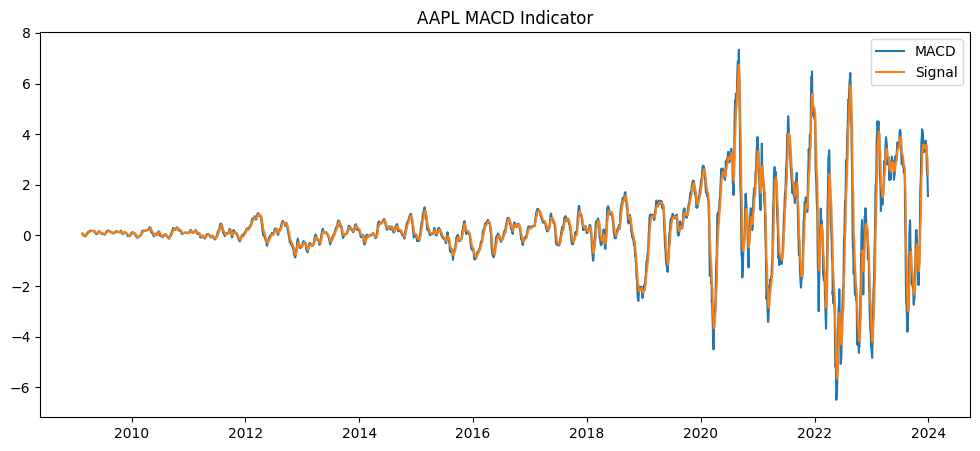

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["MACD"], label="MACD")
plt.plot(df["MACD_SIGNAL"], label="Signal")

plt.title("AAPL MACD Indicator")

plt.legend()

plt.show()